# Математический анализ - 1, ФКН ВШЭ

## Лабораторная работа 3: Градиентный спуск

### Оценивание и штрафы

Максимально допустимая оценка за работу — **10 (+3) баллов**.  После мягкого дедлайна оценка каждый день уменьшается на 1 балл до жесткого дедлайна. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis`). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено **только** в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего


**Жесткий дедлайн: 18.06.2025 23:59**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/NzExNTY1NTIzMjcy/a/Nzg1Mjc3Njc2ODcy/details)**

### О задании

В данной лабораторной работе вы познакомитесь с различными методами оптимизации, которые используются в ML задачах, и проверите их на задаче линейной регресии, а также познакомитесь с матричным и автоматическим дифференцированием, что используется при обучении нейронных сетей.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [1]:
from typing import Any, Callable

import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso



## Метод Ньютона

Пусть у нас есть гладкая функция $f: \mathbb{R}^n \longrightarrow \mathbb{R}$, точку минимума которой мы хотим найти. Вспомним, что необходимо, чтобы градиент функции был равен $0$:

$$
\nabla f(x) = 0
$$

Тогда можем свести задачу к нахождению нулей производной и использовать метод Ньютона:

$$
x_{n+1} = x_n - \alpha_n \cdot [\nabla^2 f(x_n)]^{-1} \cdot \nabla f(x_n),
$$

где $\nabla^2 f(x_n)$ — гессиан функции $f(x)$ (cимметрическая квадратичная форма, матрица вторых частных производных), $\alpha_n$ — learning rate

In [40]:
def newton_method(
    initial_point: np.ndarray,
    f: Callable[[np.ndarray], float],
    gradient: Callable[[np.ndarray], np.ndarray],
    hessian: Callable[[np.ndarray], np.ndarray],
    max_num_iter: int = 100,
    lr: float = 1.0,
    tolerance: float = 1.0e-6,
) -> tuple[np.ndarray, float, int, list[np.ndarray]]:
    """
    Newton's method for function minimization.

    Parameters
    ----------
    initial_point : np.ndarray
        The starting point for the optimization algorithm.
    f : Callable[[np.ndarray], float]
        The objective function to minimize.
    gradient : Callable[[np.ndarray], np.ndarray]
        Function that returns the gradient of f at a given point.
    hessian : Callable[[np.ndarray], np.ndarray]
        Function that returns the Hessian matrix of f at a given point.
    max_num_iter : int
        Maximum number of iterations.
    lr : float, optional
        Learning rate (step size multiplier), by default 1.0.
    tolerance : float, optional
        Convergence threshold for the norm of the gradient, by default 1.0e-6.

    Returns
    -------
    x: np.ndarray
        The final point.
    f(x) : float
        The functiom value at the final point.
    iteration : int
        The number of iteration performed before termination.
    history : list[np.ndarray]
        A list containing the points at each iteration.

    Notes
    -----
    Do not inverse hessian matrix directly!!
    """
    x = initial_point
    history = [x]
    for i in range(max_num_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < tolerance:
            max_num_iter = i
            break
        # inv(H) @ grad = p <=> H p = grad
        # => поэтому можно решить эту систему
        x = x - lr * np.linalg.solve(hessian(x), grad)
        history.append(x)
    return x, f(x), max_num_iter, history


In [41]:
def test(optimizer, params: dict[str, Any] | None = None):
    def f(x: np.ndarray) -> float:
        return np.sum(x**2)

    def gradient(x: np.ndarray) -> np.ndarray:
        return 2 * x

    def hessian(x: np.ndarray) -> np.ndarray:
        return np.array([[2.0, 0.0], [0.0, 2.0]])

    initial_point = np.random.normal(100.0, 0.1, size=2)
    print(f"Initial point: {initial_point}")

    if params is None:
        params = {"f": f, "gradient": gradient}
    params["initial_point"] = initial_point
    if optimizer == newton_method:
        params["hessian"] = hessian
    final_point, final_value, iteration, history = optimizer(**params)

    assert np.all(np.isclose(final_point, [0.0, 0.0], atol=1.0e-5)), "It works on my machine! (¬‿¬)"
    assert np.isclose(final_value, 0.0), "It works on my machine! (¬‿¬)"

    print(f"Iteration: {iteration}")
    print(f"Final point: {final_point}")
    print(f"Final function value: {final_value}")

In [42]:
test(newton_method)

Initial point: [99.90640392 99.99581307]
Iteration: 1
Final point: [0. 0.]
Final function value: 0.0


**Задание 1 (1 балл):** Подумайте (или вспомните), какие есть преимущества / недостатки у метода Ньютона. Что будет, если применить его к невыпуклой функции? Ответ обоснуйте и приведите пример. Постройте график траекторий метода Ньютона по линиям уровня для выпуклой / невыпуклой функции.

**Ответ:**

Вообще видим, что с помощью нашего метода мы нашли минимум за 1 итерацию, что очень круто.

Вспомним преимущества и недостатки

**Преимущества**:
1) Квадратичная сходимость

**Недостатки**
1) Нахождение матрицы Гессиона(а что если ее вообще нет?, а что если она не положительно определена?) и последующее решение системы(это $O(n^3)$), это не круто.
2) Если функция невыпукла, то метод может не сходится или находить не минимум.

---

Рассмотрим, например, функцию $f(x, y) = xy$. Она невыпукла. Ее градиент равен: $\nabla f(x, y) = (y, x)$. а матрица Гессиона: 

$$
\nabla^2 f(x) = 
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix}
$$

Тогда начав из любой начальной точки придем в точку $(0, 0)$, так как найденное $p = (x, y)$, то есть $x_1 = x_0 - p = (x, y) - (x, y) = 0$. Это не минимум и не максимум(а седло)!

Докажем кодом.

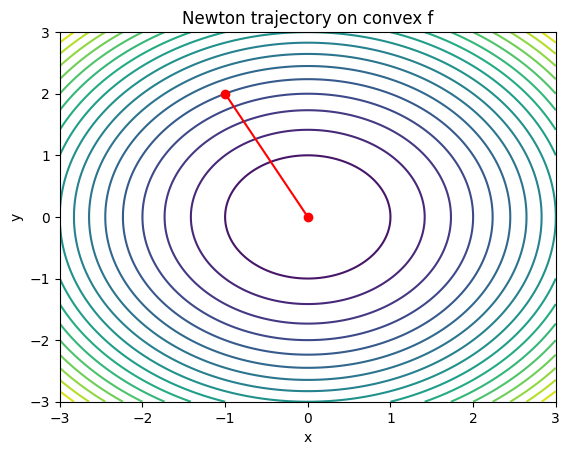

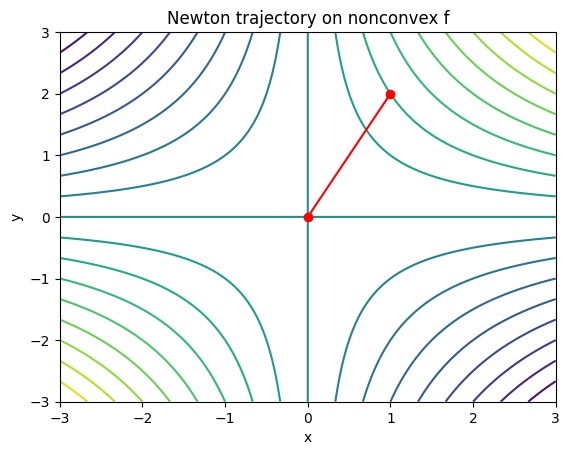

In [56]:
# f(x, y) = xy
def bad_f(x: np.ndarray) -> float:
    return x[0] * x[1]

def bad_gradient_f(x: np.ndarray) -> np.ndarray:
    return np.array([x[1], x[0]])

def bad_hessian_f(x: np.ndarray) -> np.ndarray:
    return np.array([[0.0, 1.0], [1.0, 0.0]])

# f(x, y) = x^2 + y^2
def good_f(x: np.ndarray) -> float:
        return np.sum(x**2)

def good_gradient_f(x: np.ndarray) -> np.ndarray:
        return 2 * x

def good_hessian_f(x: np.ndarray) -> np.ndarray:
        return np.array([[2.0, 0.0], [0.0, 2.0]])



def print_newton_traj(initial_point, f, grad, hess, s):
    x1 = np.linspace(-3, 3, 400)
    x2 = np.linspace(-3, 3, 400)
    # делаем квадратную сетку размера 400 x 400
    X1_mat, X2_mat = np.meshgrid(x1, x2)

    # чтобы посчитать функцию нужно из сетки сделать линейный массив
    X = np.stack([X1_mat.ravel(), X2_mat.ravel()], axis=1)
    Z = np.array([ f(pt) for pt in X ]) 
    Z_mat = Z.reshape(X1_mat.shape)

    final_x, final_y, number_of_iter, history = newton_method(initial_point, f, grad, hess, 10)

    # Делаем нормальную форму для истории
    hist = np.vstack(history)

    plt.figure()
    plt.contour(X1_mat, X2_mat, Z_mat, levels=20)
    plt.plot(hist[:,0], hist[:,1], marker='o', color='red')
    plt.title(s)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

print_newton_traj(np.array([-1.0, 2.0]), good_f, good_gradient_f, good_hessian_f, "Newton trajectory on convex f")
print_newton_traj(np.array([1.0, 2.0]), bad_f, bad_gradient_f, bad_hessian_f, "Newton trajectory on nonconvex f")


## Градиентный спуск

Теперь перейдем к тому, чем пользуются в ML, а именно к градиентному спуску (gradient descent, GD). Наивная реализация следующая:

$$
x_{n + 1} = x_n - \alpha_n \nabla f(x_n),
$$

где $\alpha_n$ — learning rate

In [ ]:
def gradient_descent(
    initial_point: np.ndarray,
    f: Callable[[np.ndarray], float],
    gradient: Callable[[np.ndarray], np.ndarray],
    max_num_iter: int = 10000,
    lr: float = 0.001,
    tolerance: float = 1.0e-6,
) -> tuple[np.ndarray, float, int, list[np.ndarray]]:
    """
    Gradient descent algorithm for function minimization.

    Parameters
    ----------
    initial_point : np.ndarray
        The starting point for the optimization algorithm.
    f : Callable[[np.ndarray], float]
        The objective function to minimize.
    gradient : Callable[[np.ndarray], np.ndarray]
        Function that returns the gradient of f at a given point.
    max_num_iter : int
        Maximum number of iterations.
    lr : float, optional
        Learning rate (step size multiplier), by default 1.0.
    tolerance : float, optional
        Convergence threshold for the norm of the gradient, by default 1.0e-6.

    Returns
    -------
    x: np.ndarray
        The final point.
    f(x) : float
        The functiom value at the final point.
    iteration : int
        The number of iteration performed before termination.
    history : list[np.ndarray]
        A list containing the points at each iteration.
    """
    # Waiting for implement (⌐■_■)
    raise NotImplementedError

In [ ]:
test(gradient_descent)

**Задание 2 (1 балл):** что будет при больших и маленьких learning rate? Подтвердите свой ответ графиками.

**Ответ:**

## Координатный спуск

Существует еще один оптимизационный алгоритм — покоординатный спуск (Coordinate Descent). На каждом шаге выбираем индекс $i$ и меняем $i$-ую координату по формуле:

$$
x_{n + 1}^{(i)} = x_{n}^{(i)} - \alpha_n \frac{df}{dx_n^{(i)}}(x_n)
$$

In [ ]:
def coordinate_descent(
    initial_point: np.ndarray,
    f: Callable[[np.ndarray], float],
    gradient: Callable[[np.ndarray], np.ndarray],
    max_num_iter: int = 10000,
    lr: float = 0.001,
    tolerance: float = 1.0e-6,
) -> tuple[np.ndarray, float, int, list[np.ndarray]]:
    """
    Coordinate descent algorithm for function minimization.

    Parameters
    ----------
    initial_point : np.ndarray
        The starting point for the optimization algorithm.
    f : Callable[[np.ndarray], float]
        The objective function to minimize.
    gradient : Callable[[np.ndarray], np.ndarray]
        Function that returns the gradient of f at a given point.
    max_num_iter : int
        Maximum number of iterations.
    lr : float, optional
        Learning rate (step size multiplier), by default 1.0.
    tolerance : float, optional
        Convergence threshold for the norm of the gradient, by default 1.0e-6.

    Returns
    -------
    x: np.ndarray
        The final point.
    f(x) : float
        The functiom value at the final point.
    iteration : int
        The number of iteration performed before termination.
    history : list[np.ndarray]
        A list containing the points at each iteration.
    """
    # Waiting for implement (⌐■_■)
    raise NotImplementedError

In [ ]:
test(coordinate_descent)

**Задание 3 (2 балла):** Сравните все три метода между собой на следующих двумерных функциях:

- $f(x, y) = -20\exp\left(-0.2\sqrt{0.5(x^2 + y^2)}\right) - \exp\Big(0.5(\cos(2\pi x) + \cos(2\pi y)\Big) + 20 + e$
- $f(x, y) = (1 - x)^2 + 100(y - x^2)^2$
- $f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$

Постройте траектории сходимости с разными параметрами (начальные точки, learning rate, ...). Выберите лучший.

Для вычислений градиентов и гессианов можно применять численные методы (см. лабораторная-1).

**Ответ:**

In [ ]:
# Waiting for implement (⌐■_■)

## Матричное дифференцирование

Пусть у нас есть функция $f: \mathbb{R}^m \longrightarrow \mathbb{R}^n$. В задачах оптимизации часто используют градиентные методы, поэтому нужно уметь считать производные через отдельные координаты и индексы слишком громоздко и неоптимизировано. Поэтому научимся вычислять производные в матричном виде

Функция $f(x)$ дифференцируема в точке $x_0$, если

$$
f(x_0 + h) = f(x_0) + [D_{x_0} f](h) + o(\lVert h \rVert),
$$

где $[D_{x_0} f]$ — дифференциал функции $f$, норма евклидова

Примеры:
- $f(x)$ — скалярная функция, $x$ — число
    $$
    f(x_0 + h) - f(x_0) \approx f'(x_0) h
    $$

    $$
    [D_{x_0} f] = f'(x_0) h
    $$

- $f(x)$ — скалярная функция, $x$ — вектор
    $$
    f(x_0 + h) - f(x_0) \approx \sum\limits_{i} \frac{\partial f}{\partial x_i}\Big|_{x=x_0} h_i
    $$

    $$
    [D_{x_0} f] = (\nabla_{x_0} f)^{\top} h = \langle \nabla_{x_0} f, h \rangle
    $$


**Задание 4 (1 балл):** Вычислите дифференциал и градиент функций: (сначала по координатам, потом с помощью матричных выражений)

- $f(x) = \langle a, x \rangle, a \in \mathbb{R}$
- $f(x) = \langle Ax, x \rangle, A \in \mathbb{R}^{n \times n}$ - постоянная матрица
- $f(x) = \lVert Ax - b \rVert^2$

**Ответ:**



## Линейная регрессия

Решим задачу оптимизации линейной регрессии $f(x) = \lVert Ax - y\rVert^2$, $A \in \mathbb{R}^{N \times n}, y \in \mathbb{R}^N$ и требуется найти минимум этой функции

**Задание 5 (2 балл):** Проверьте также все три метода на этой задаче. Какие выводы можно сделать? Насколько эффективные методы?

**Ответ:**

In [ ]:
diabetes = load_diabetes()

A, y = diabetes["data"], diabetes["target"]
# для лучшей сходимости
A = (A - A.mean(axis=0)) / A.std(axis=0)
y = (y - y.mean()) / y.std()


def f(x: np.ndarray) -> float:
    # Waiting for implement (⌐■_■)
    raise NotImplementedError


def gradient(x: np.ndarray) -> np.ndarray:
    # Waiting for implement (⌐■_■)
    raise NotImplementedError

In [ ]:
# Waiting for implement (⌐■_■)

## Стохастический градиентный спуск

Рассмотрим следующую задачу оптимизации для нахождения минимума функции:

$$
f(x) = \frac{1}{N}\sum\limits_{i = 1}^N (y_i - a_i^{\top} x)^2, \quad a_i \in \mathbb{R}^n,
$$

или, в более компактной записи:

$$
f(x) = \frac{1}{N}\sum\limits_{i = 1}^N f_i(x),
$$

где $f_i(x) = (y_i - a_i^\top x)^2$, где $a_i$ — строки матрицы $A \in \mathbb{R}^{N \times n}$, $y_i$ — $i$-ая координата вектора $y \in \mathbb{R}^N$

Если $N$ достаточно велико, то вычисление $\nabla f(x)$ на каждом шаге градиентного спуска может быть слишком затратным по ресурсам. Поэтому на практике часто применяют различные аппроксимации градиента, например, **стохастический градиентный спуск (SGD)**:

$$
x_{n + 1} = x_n - \alpha_n g(x_n),
$$

где $g(x_n)$ — аппроксимация градиента


Один из вариантов аппроксимации — вычислять градиент по **одному случайному индексу** $i \in \{1, \ldots, N\}$:

$$
g(x_n) = \frac{\partial f_i}{\partial x}(x_n).
$$

Также можно выбирать несколько случайных индексов $i_n \subset \{1, \ldots, N\}$ и вычислять градиент по ним (такой подход называют **mini-batch SGD**):

$$
g(x_n) = \frac{1}{|i_n|} \sum\limits_{i \in i_n} \frac{\partial f_i}{\partial x}(x_n).
$$


**Бонус 1 (1 балл):** реализуйте mini-batch SGD и проверьте на задаче из секции линейной регрессии. Сравните с другими методами: чем хуже / лучше?

In [ ]:
diabetes = load_diabetes()

A, y = diabetes["data"], diabetes["target"]
# для лучшей сходимости
A = (A - A.mean(axis=0)) / A.std(axis=0)
y = (y - y.mean()) / y.std()

# Waiting for implement (⌐■_■)

## Регуляризация

Рассмотрим следующую задачу оптимизации для нахождения минимума функции:

$$
f(x) = \frac{1}{2N} \sum\limits_{i=1}^N \left( y_i - a_i^\top x \right)^2 + \lambda \|x\|_1, \quad a_i \in \mathbb{R}^n,
$$

где:

- $\lambda > 0$ — гиперпараметр L1-регуляризации
- $\|x\|_1 = \sum\limits_{j=1}^n |x_j|$ — сумма модулей компонент вектора $x$
- $a_i$ — строки матрицы $A \in \mathbb{R}^{N \times n}$, $y_i$ — $i$-ая координата вектора $y \in \mathbb{R}^N$

**Задание (3 балла):**

- Напишите формулу для вычисления градиентов в матричной форме для Coordinate Descent

- Реализуйте метод Coordinate Descent (координатный спуск) для решения задачи из секции линейной регрессии с L1-регуляризацией, используя циклический порядок обновления координат

- Проведите эксперименты с разными значениями $\lambda$

- Сравните результаты Coordinate Descent с другими методами оптимизации:
    - Есть ли различия в полученных решениях?
    - Сравните решения с результатами, полученными с помощью функции `Lasso` из библиотеки `scikit-learn`.


**Ответ:**


In [ ]:
diabetes = load_diabetes()

A, y = diabetes["data"], diabetes["target"]
# для лучшей сходимости
A = (A - A.mean(axis=0)) / A.std(axis=0)
y = (y - y.mean()) / y.std()

# Waiting for implement (⌐■_■)

## Автоматическое дифференцирование

В прошлом мы рассматривали методы численного дифференцирования. Они были простые, но у них было несколько недостатков: точность и нестабильность. Можно также использовать символьное дифференцирование, которое работает медленно и может создавать большие выражения. 

На смену этим двум методам был придуман еще один способ считать производные — автоматическое дифференцирование. Суть в том, чтобы создать граф вычислений и использовать правило сложной производной (chain rule):

$$
h = f(g(x)) \implies \frac{\partial h}{\partial x} = \frac{\partial f}{\partial g} \cdot \frac{\partial g}{\partial x}
$$

Пример: рассмотрим функцию

$$
f(x) = \sin(x^2 + 3x)
$$

**Промежуточные вычисления (граф):**

1. $u = x^2$
2. $v = 3x$
3. $w = u + v$
4. $f = \sin(w)$

Теперь можно применять chain rule в обратном порядке:

$$
\frac{df}{dx} = \frac{df}{dw} \cdot \left( \frac{dw}{du} \cdot \frac{du}{dx} + \frac{dw}{dv} \cdot \frac{dv}{dx} \right) = \cos(w) \cdot (2x + 3)
$$


**Бонус 2 (2 балла):** Реализуйте класс `Value` для автоматического дифференцирования и посчитайте градиент функции. Сравните с численными методами вычисления производных (частные производные вычисляются так же, как и одномерные)

В качестве примера возьмите функции из задания 3 и функцию 

$$
f(x, y, z) = \sin(\exp(xy) + \cos(z) \cdot \sqrt{|y| + 1)})
    + \log(z^2 + x) \cdot \tanh(y - xz)
    + (x^2 + y^2 + z^2)^{1 / 3}
$$

In [ ]:
class Value:
    def __init__(self, data: float, _prev=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._prev = set(_prev)  # узлы-предки
        self._op = _op  # метка операции
        self._backward = lambda: None  # лямбда с локальным backprop

    # ---------- базовые арифметические операции ----------
    def __add__(self, other):  # self + other
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __radd__(self, other):  # other + self
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __mul__(self, other):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    __rmul__ = __mul__

    def __neg__(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __sub__(self, other):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __rsub__(self, other):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __truediv__(self, other):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __rtruediv__(self, other):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __pow__(self, exponent):
        assert isinstance(exponent, (int, float)), "степень должна быть числом"
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    # ---------- элемент-функции ----------
    def abs(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def tanh(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def exp(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def sin(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def cos(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def sqrt(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def log(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    # ---------- запуск обратного прохода ----------
    def backward(self):
        # Waiting for implement (⌐■_■)
        raise NotImplementedError

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(data={self.data}, grad={self.grad})"


In [6]:
def absolute(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.abs()


def tanh(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.tanh()


def exp(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.exp()


def sin(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.sin()


def cos(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.cos()


def sqrt(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.sqrt()


def log(x):
    x = x if isinstance(x, Value) else Value(x)
    return x.log()


def pow(x, exponent):
    x = x if isinstance(x, Value) else Value(x)
    return x**exponent

In [ ]:
# Waiting for implement (⌐■_■)